In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and split data
X, y = make_circles(n_samples=2000, noise=0.33, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Dictionary to store final weights for each configuration
saved_weights = {}

# Dictionary to store history for plotting
histories = {}

# Configurations to loop through
configs = ['None', 'L1', 'L2']

for config in configs:
    print(f"\n--- Training Model with {config} Regularization ---")

    torch.manual_seed(42)
    
    # 2. Re-initialize the model for each run to reset weights
    model = nn.Sequential(
        nn.Linear(2, 500),
        nn.ReLU(),
        nn.Linear(500, 500),
        nn.ReLU(),
        nn.Linear(500, 2)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    epoch_ticks = []
    train_accuracies = []
    test_accuracies = []

    # 4. Training Loop
    epochs = 2000
    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        # Apply specific regularization penalty
        if config == 'L1':
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss = loss + (0.004 * l1_penalty)
        elif config == 'L2':
            l2_penalty = sum((p ** 2).sum() for p in model.parameters())
            loss = loss + (0.050 * l2_penalty)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics every 25 epochs
        if (epoch + 1) % 25 == 0:
            model.eval()
            with torch.no_grad():
                _, train_predicted = torch.max(outputs, 1)
                train_acc = (train_predicted == y_train).sum().item() / y_train.size(0)
                
                test_outputs = model(X_test)
                _, test_predicted = torch.max(test_outputs, 1)
                test_acc = (test_predicted == y_test).sum().item() / y_test.size(0)
            
            epoch_ticks.append(epoch + 1)
            train_accuracies.append(train_acc)
            test_accuracies.append(test_acc)
            
            if (epoch + 1) % 500 == 0:  # Reduced print frequency for cleaner console output
                print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Train Acc: {train_acc*100:.1f}% | Test Acc: {test_acc*100:.1f}%")

    # Store histories for the plotting step
    histories[config] = {
        'ticks': epoch_ticks,
        'train': train_accuracies,
        'test': test_accuracies
    }
    
    # Store final flattened model weights as a NumPy array
    saved_weights[config] = np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])


--- Training Model with None Regularization ---
Epoch [500/2000] | Loss: 0.4660 | Train Acc: 78.2% | Test Acc: 76.9%
Epoch [1000/2000] | Loss: 0.4600 | Train Acc: 78.2% | Test Acc: 76.2%
Epoch [1500/2000] | Loss: 0.4585 | Train Acc: 78.2% | Test Acc: 76.1%
Epoch [2000/2000] | Loss: 0.4575 | Train Acc: 78.1% | Test Acc: 76.2%

--- Training Model with L1 Regularization ---
Epoch [500/2000] | Loss: 9.5638 | Train Acc: 77.6% | Test Acc: 77.5%
Epoch [1000/2000] | Loss: 2.9645 | Train Acc: 77.5% | Test Acc: 77.0%
Epoch [1500/2000] | Loss: 2.4751 | Train Acc: 77.6% | Test Acc: 77.4%
Epoch [2000/2000] | Loss: 2.2986 | Train Acc: 78.0% | Test Acc: 77.4%

--- Training Model with L2 Regularization ---
Epoch [500/2000] | Loss: 8.3553 | Train Acc: 77.8% | Test Acc: 77.2%
Epoch [1000/2000] | Loss: 3.5154 | Train Acc: 77.8% | Test Acc: 77.0%
Epoch [1500/2000] | Loss: 1.7557 | Train Acc: 77.6% | Test Acc: 77.0%
Epoch [2000/2000] | Loss: 1.1164 | Train Acc: 78.0% | Test Acc: 77.0%


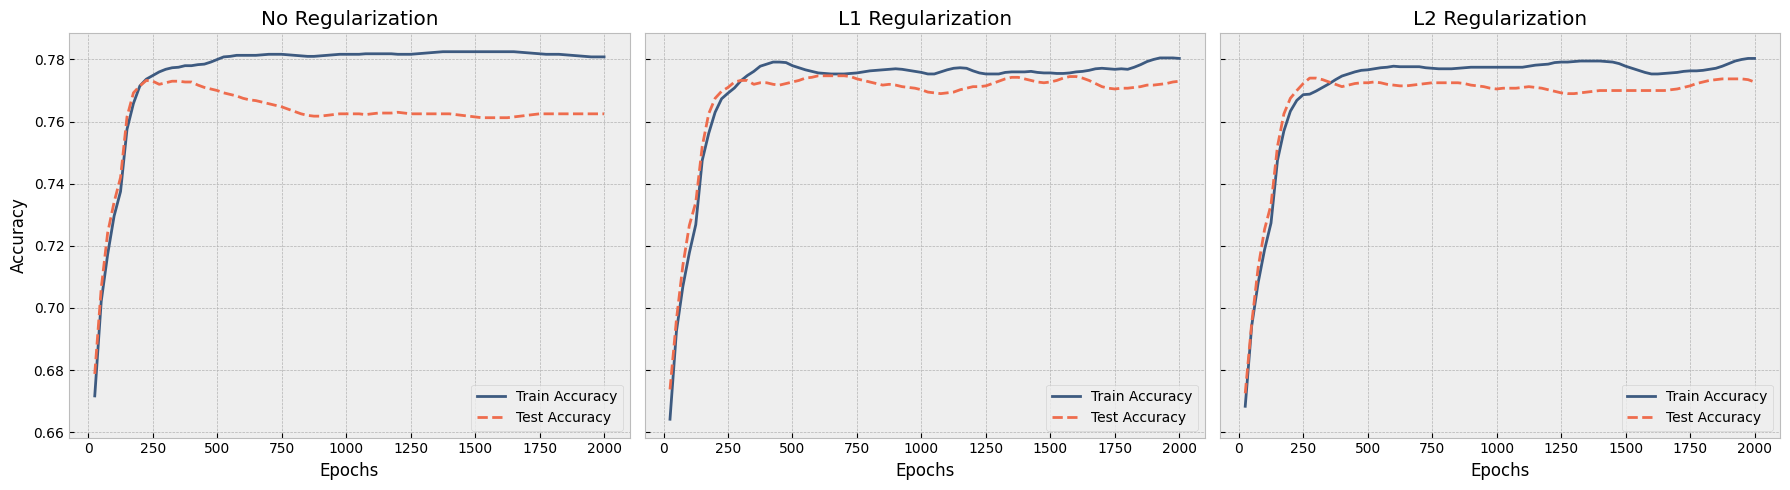

In [61]:
plt.style.use('bmh')
colors = ["#3d5a80", "#ee6c4d"]
window_size = 5

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = {
    'None': 'No Regularization',
    'L1': 'L1 Regularization',
    'L2': 'L2 Regularization'
}

for idx, config in enumerate(configs):
    ax = axes[idx]
    hist = histories[config]
    
    smooth_train = pd.Series(hist['train']).rolling(window=window_size, min_periods=1).mean()
    smooth_test = pd.Series(hist['test']).rolling(window=window_size, min_periods=1).mean()
    
    ax.plot(hist['ticks'], smooth_train, label='Train Accuracy', color=colors[0], linewidth=2)
    ax.plot(hist['ticks'], smooth_test, label='Test Accuracy', color=colors[1], linewidth=2, linestyle='--')
    
    ax.set_title(titles[config])
    ax.set_xlabel('Epochs')
    if idx == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('regularization_training.png')
plt.show()

In [62]:
print("\n--- Weight Analysis ---")
for config, weights in saved_weights.items():
    # 1. Calculate L1 Norm (sum of absolute values)
    l1_norm = np.sum(np.abs(weights))
    
    # 2. Calculate L2 Norm (Euclidean norm)
    l2_norm = np.linalg.norm(weights)
    
    # 3. Calculate Sparsity (% of weights that close to 0)
    threshold = 1e-4
    zero_weights = np.sum(np.abs(weights) < threshold)
    sparsity_pct = (zero_weights / weights.size) * 100
    
    print(f"Configuration: {config}")
    print(f"  L1 Norm:     {l1_norm:.4f}")
    print(f"  L2 Norm:     {l2_norm:.4f}")
    print(f"  Sparsity:    {sparsity_pct:.2f}% ({zero_weights} out of {weights.size} elements)")
    print("-" * 30)


--- Weight Analysis ---
Configuration: None
  L1 Norm:     6193.7129
  L2 Norm:     20.5657
  Sparsity:    0.23% (589 out of 253002 elements)
------------------------------
Configuration: L1
  L1 Norm:     451.7051
  L2 Norm:     13.4620
  Sparsity:    99.12% (250768 out of 253002 elements)
------------------------------
Configuration: L2
  L1 Norm:     922.3664
  L2 Norm:     3.1774
  Sparsity:    1.60% (4053 out of 253002 elements)
------------------------------
